# Lab 9 - Advanced Pandas
## Objectives

In this lab, you'll learn advanced data manipulation techniques in pandas using the IMDb Movies dataset.
You'll practice hierarchical indexing, complex transformations, efficient filtering, and data optimization.



### Upon completion of this lab, you'll be able to:

- Work with MultiIndex and hierarchical data
- Apply user-defined functions and transformations (apply, map, transform)
- Use query() and eval() for efficient filtering
- Optimize memory usage and work with categorical variables


# Dataset

## imdb_movies.csv

**Columns:**
- `names` - Movie title
- `date_x` - Release date
- `score` - Rating (0-10)
- `genre` - Genre
- `overview` - Description
- `crew` - Film crew
- `orig_title` - Original title
- `status` - Release status
- `orig_lang` - Original language
- `budget_x` - Budget (USD)
- `revenue` - Box office receipts (USD)
- `country` - Country of origin

# Part 1 - Data Loading and Preparation



### Tasks:

1. **Load the dataset** into a DataFrame named `df`

2. **Examine the data structure:**
- Print basic information (`df.info()`)
- Check the number of missing values
- Print the first 5 rows

3. **Rename columns** for consistency:
- `budget_x` → `budget`
- `date_x` → `release_date`

4. **Convert data types:**
- Convert `release_date` to datetime format
- Replace missing values ​​in `budget` and `revenue` with 0

5. **Create a new column** `profit = revenue - budget`


### Verification:
After execution, you should have a DataFrame with a `profit` column and no gaps in `budget`/`revenue`.

In [1]:
import pandas as pd
import numpy as np
import os

# Task 1: Load the dataset
file_path = '9/imdb_movies.csv'

if not os.path.exists(file_path):
    print(f"❌ ОШИБКА: Файл не найден: {file_path}")
    print(f"Текущая директория: {os.getcwd()}")
    print("\nУбедитесь, что:")
    print("1. Вы запускаете код из папки python_minor/")
    print("2. Файл imdb_movies.csv находится в папке 9/")
    raise FileNotFoundError(f"Файл {file_path} не найден")
else:
    df = pd.read_csv(file_path)
    print(f"✅ Файл успешно загружен: {len(df)} строк, {len(df.columns)} колонок")

# Task 2: Examine the data structure
print("=" * 60)
print("BASIC INFORMATION")
print("=" * 60)
df.info()

BASIC INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10178 entries, 0 to 10177
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   names       10178 non-null  object 
 1   date_x      10178 non-null  object 
 2   score       10178 non-null  float64
 3   genre       10093 non-null  object 
 4   overview    10178 non-null  object 
 5   crew        10122 non-null  object 
 6   orig_title  10178 non-null  object 
 7   status      10178 non-null  object 
 8   orig_lang   10178 non-null  object 
 9   budget_x    10178 non-null  float64
 10  revenue     10178 non-null  float64
 11  country     10178 non-null  object 
dtypes: float64(3), object(9)
memory usage: 954.3+ KB

MISSING VALUES COUNT
genre    85
crew     56
dtype: int64

FIRST 5 ROWS
                         names       date_x  score  \
0                    Creed III  03/02/2023    73.0   
1     Avatar: The Way of Water  12/15/2022    78.0   
2  The Sup

# Part 2 - MultiIndex and Hierarchical Operations


### Tasks:

1. **Create a MultiIndex DataFrame:**
- Group the data by `country` and `genre`
- Set these columns as MultiIndex

2. **Calculate aggregated metrics:**
- Average `score` for each pair (country, genre)
- Total `revenue` for each pair (country, genre)
- Store the result in a DataFrame `multi_df`

3. **Use `.unstack()`:**
- Expand `genre` into columns
- Examine the resulting structure

4. **Working with MultiIndex:**
- Get all data for the US (United States of America)
- Display the top 3 genres by average rating for the US

5. **Compare Structures:**
- Use `.reset_index()` and compare the original and new DataFrames
- Explain the difference in 1-2 sentences

### Hint:
```python
# Creating a MultiIndex via groupby:
multi_df = df.groupby(['country', 'genre']).agg({
'score': 'mean',
'revenue': 'sum'
})

# Accessing country data:
multi_df.loc['US']
```


In [5]:
import pandas as pd
import numpy as np


print("=" * 70)
print("TASK 1 & 2: CREATE MULTIINDEX DATAFRAME WITH AGGREGATED METRICS")
print("=" * 70)

# Task 1 & 2: Create MultiIndex DataFrame with aggregated metrics
multi_df = df.groupby(['country', 'genre']).agg({
    'score': 'mean',
    'revenue': 'sum'
})

print("\nMultiIndex DataFrame created!")
print(f"Shape: {multi_df.shape}")
print(f"\nFirst 10 rows:")
print(multi_df.head(10))

print(f"\nIndex levels: {multi_df.index.names}")
print(f"Number of unique countries: {multi_df.index.get_level_values('country').nunique()}")
print(f"Number of unique genres: {multi_df.index.get_level_values('genre').nunique()}")

print("\n" + "=" * 70)
print("TASK 3: USE .unstack() TO EXPAND GENRE INTO COLUMNS")
print("=" * 70)

# Task 3: Use unstack() to expand genre into columns
unstacked_score = multi_df['score'].unstack()
unstacked_revenue = multi_df['revenue'].unstack()

print("\nUnstacked Score DataFrame (genre as columns):")
print(f"Shape: {unstacked_score.shape}")
print(f"\nFirst 5 countries:")
print(unstacked_score.head())

print("\n\nUnstacked Revenue DataFrame (genre as columns):")
print(f"Shape: {unstacked_revenue.shape}")
print(f"\nFirst 5 countries:")
print(unstacked_revenue.head())

print("\n" + "=" * 70)
print("TASK 4: WORKING WITH MULTIINDEX - US DATA")
print("=" * 70)

# Task 4: Get all data for the US
try:
    us_data = multi_df.loc['US']
    print("\nAll data for United States (US):")
    print(us_data)
    
    # Display top 3 genres by average rating for US
    top3_us_genres = us_data.nlargest(3, 'score')
    print("\n" + "-" * 70)
    print("TOP 3 GENRES BY AVERAGE RATING FOR US:")
    print("-" * 70)
    print(top3_us_genres)
    
except KeyError:
    print("\n⚠️ 'US' not found in index. Checking available country codes...")
    print("\nUnique countries in dataset:")
    countries = multi_df.index.get_level_values('country').unique()
    print(countries[:20])  # Показываем первые 20
    
    # Попробуем найти США по другому коду
    us_variations = ['US', 'USA', 'United States', 'United States of America']
    for country_code in us_variations:
        if country_code in countries:
            print(f"\n✓ Found USA as: '{country_code}'")
            us_data = multi_df.loc[country_code]
            print(f"\nAll data for {country_code}:")
            print(us_data)
            
            top3_us_genres = us_data.nlargest(3, 'score')
            print("\n" + "-" * 70)
            print(f"TOP 3 GENRES BY AVERAGE RATING FOR {country_code}:")
            print("-" * 70)
            print(top3_us_genres)
            break

print("\n" + "=" * 70)
print("TASK 5: COMPARE STRUCTURES - RESET_INDEX()")
print("=" * 70)

# Task 5: Compare structures
multi_df_reset = multi_df.reset_index()

print("\nORIGINAL MultiIndex DataFrame:")
print(f"Type: {type(multi_df.index)}")
print(f"Shape: {multi_df.shape}")
print(f"Index: {multi_df.index.names}")
print(f"Columns: {multi_df.columns.tolist()}")
print("\nFirst 5 rows:")
print(multi_df.head())

print("\n" + "-" * 70)

print("\nDataFrame after .reset_index():")
print(f"Type: {type(multi_df_reset.index)}")
print(f"Shape: {multi_df_reset.shape}")
print(f"Index: {multi_df_reset.index.name}")
print(f"Columns: {multi_df_reset.columns.tolist()}")
print("\nFirst 5 rows:")
print(multi_df_reset.head())

print("\n" + "=" * 70)
print("EXPLANATION OF DIFFERENCES:")
print("=" * 70)
print("""
DIFFERENCE EXPLANATION:
The original MultiIndex DataFrame uses 'country' and 'genre' as hierarchical 
index levels, allowing efficient slicing (e.g., multi_df.loc['US']).
After reset_index(), these become regular columns with a simple RangeIndex, 
making the data easier to work with for certain operations but losing the 
hierarchical querying capability.
""")

# Дополнительная статистика
print("\n" + "=" * 70)
print("ADDITIONAL STATISTICS")
print("=" * 70)

print("\nTop 5 Country-Genre combinations by Revenue:")
print(multi_df.nlargest(5, 'revenue'))

print("\nTop 5 Country-Genre combinations by Average Score:")
print(multi_df.nlargest(5, 'score'))

TASK 1 & 2: CREATE MULTIINDEX DATAFRAME WITH AGGREGATED METRICS

MultiIndex DataFrame created!
Shape: (3820, 2)

First 10 rows:
                                           score       revenue
country genre                                                 
AR      Animation, Adventure, Romance  66.000000  1.392649e+06
        Comedy                         77.750000  3.062086e+09
        Comedy, Drama                  64.000000  3.654706e+08
        Comedy, Drama, Family          78.000000  4.610992e+08
        Comedy, Romance, Thriller      76.000000  5.431289e+08
        Comedy, Thriller, Crime        78.000000  7.627100e+06
        Crime                          55.000000  9.352440e+08
        Crime, Thriller                71.000000  4.066915e+08
        Documentary                    61.333333  1.676055e+09
        Drama                          77.000000  3.698620e+08

Index levels: ['country', 'genre']
Number of unique countries: 58
Number of unique genres: 2303

TASK 3: USE .unsta

# Part 3 - Custom Functions and apply/map/transform



### Tasks:

1. **Create a function to classify movie success:**

Write a function `classify_performance(row)` that returns a category based on the following criteria:
- **'Blockbuster'**: `profit > 100,000,000` AND `score >= 7.0`
- **'Successful'**: `profit > 0` AND `score >= 6.0`
- **'Average'**: `profit > 0` OR `score >= 5.0`
- **'Flop'**: all other cases

2. **Apply the function:**
- Use `.apply()` with `axis=1` to create the `performance` column
- Count the number of movies in each category

3. **Use `.map()` for language normalization:**

Create a mapping dictionary:
```python
lang_map = {
'English': 'EN',
'French': 'FR',
'Spanish': 'ES',
'German': 'DE',
'Japanese': 'JP'
# ... add others as needed
}
```
- Apply `.map()` to the `orig_lang` column
- For unknown languages, leave 'OTHER'

4. **Grouping with analysis:**
- Group by `country` and `performance`
- Calculate the average `score` and average `profit`
- Plot a bar chart showing average rating (score) by genre
- Sort by average profit (descending)

5. **Compare transformation methods:**

Using the example of grouping by `genre`, compare the outputs of .apply(), .agg(), and .transform() with the same group

Explain the difference in result sizes and when to use each.

###  Tips:
```python
# Classification function:
def classify_performance(row):
    if row['profit'] > 100_000_000 and row['score'] >= 7.0:
        return 'Blockbuster'
'
# ... continue

# Application:
df['performance'] = df.apply(classify_performance, axis=1)



TASK 1: CREATE CLASSIFICATION FUNCTION
Function 'classify_performance' created!

Classification criteria:
  - Blockbuster: profit > $100M AND score >= 7.0
  - Successful:  profit > $0 AND score >= 6.0
  - Average:     profit > $0 OR score >= 5.0
  - Flop:        all other cases

TASK 2: APPLY THE FUNCTION

'performance' column created!

Sample data with performance classification:
                          names        profit  score  performance
0                     Creed III  1.966167e+08   73.0  Blockbuster
1      Avatar: The Way of Water  1.856795e+09   78.0  Blockbuster
2   The Super Mario Bros. Movie  6.244590e+08   76.0  Blockbuster
3                       Mummies  2.190000e+07   70.0   Successful
4                     Supercell  2.639420e+08   61.0  Blockbuster
5                  Cocaine Bear  4.500000e+07   66.0   Successful
6          John Wick: Chapter 4  2.513494e+08   80.0  Blockbuster
7  Puss in Boots: The Last Wish  3.934806e+08   83.0  Blockbuster
8               Attack

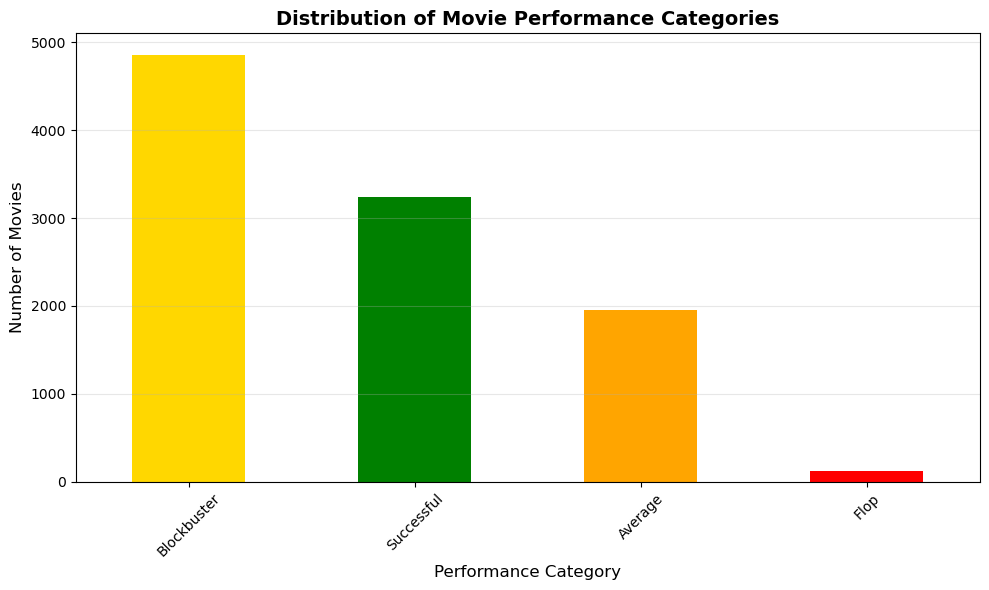


TASK 3: USE .map() FOR LANGUAGE NORMALIZATION

Unique languages in dataset:
orig_lang
English               7417
Japanese               714
Spanish, Castilian     397
Korean                 388
French                 285
Chinese                153
Cantonese              145
Italian                142
German                  93
Russian                 66
Tagalog                 43
Portuguese              35
Thai                    34
Norwegian               29
Polish                  26
Hindi                   26
Danish                  23
Dutch, Flemish          22
Swedish                 22
Turkish                 22
Name: count, dtype: int64

----------------------------------------------------------------------
LANGUAGE NORMALIZATION APPLIED
----------------------------------------------------------------------

Language code distribution:
lang_code
OTHER    10178
Name: count, dtype: int64

Sample comparison (original vs normalized):
                          names            orig_

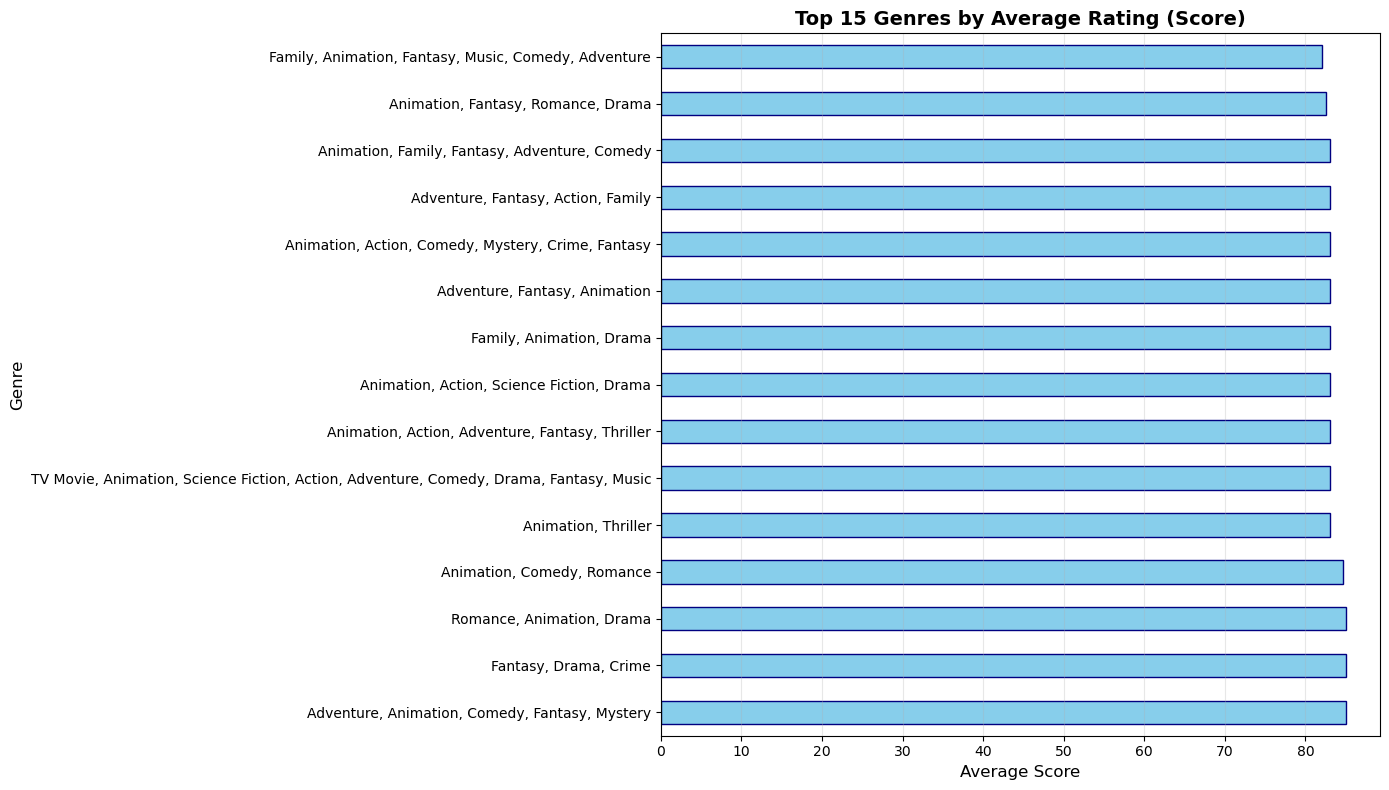


Average score by genre (top 15):
genre
Adventure, Animation, Comedy, Fantasy, Mystery                                            85.000000
Fantasy, Drama, Crime                                                                     85.000000
Romance, Animation, Drama                                                                 85.000000
Animation, Comedy, Romance                                                                84.666667
Animation, Thriller                                                                       83.000000
TV Movie, Animation, Science Fiction, Action, Adventure, Comedy, Drama, Fantasy, Music    83.000000
Animation, Action, Adventure, Fantasy, Thriller                                           83.000000
Animation, Action, Science Fiction, Drama                                                 83.000000
Family, Animation, Drama                                                                  83.000000
Adventure, Fantasy, Animation                               

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


print("=" * 70)
print("TASK 1: CREATE CLASSIFICATION FUNCTION")
print("=" * 70)

# Task 1: Create a function to classify movie success
def classify_performance(row):
    """
    Classify movie performance based on profit and score.
    
    Returns:
        - 'Blockbuster': profit > 100M AND score >= 7.0
        - 'Successful': profit > 0 AND score >= 6.0
        - 'Average': profit > 0 OR score >= 5.0
        - 'Flop': all other cases
    """
    if row['profit'] > 100_000_000 and row['score'] >= 7.0:
        return 'Blockbuster'
    elif row['profit'] > 0 and row['score'] >= 6.0:
        return 'Successful'
    elif row['profit'] > 0 or row['score'] >= 5.0:
        return 'Average'
    else:
        return 'Flop'

print("Function 'classify_performance' created!")
print("\nClassification criteria:")
print("  - Blockbuster: profit > $100M AND score >= 7.0")
print("  - Successful:  profit > $0 AND score >= 6.0")
print("  - Average:     profit > $0 OR score >= 5.0")
print("  - Flop:        all other cases")

print("\n" + "=" * 70)
print("TASK 2: APPLY THE FUNCTION")
print("=" * 70)

# Task 2: Apply the function to create performance column
df['performance'] = df.apply(classify_performance, axis=1)

print("\n'performance' column created!")
print("\nSample data with performance classification:")
print(df[['names', 'profit', 'score', 'performance']].head(10))

# Count the number of movies in each category
performance_counts = df['performance'].value_counts()
print("\n" + "-" * 70)
print("NUMBER OF MOVIES IN EACH CATEGORY:")
print("-" * 70)
print(performance_counts)

# Visualize the distribution
plt.figure(figsize=(10, 6))
performance_counts.plot(kind='bar', color=['gold', 'green', 'orange', 'red'])
plt.title('Distribution of Movie Performance Categories', fontsize=14, fontweight='bold')
plt.xlabel('Performance Category', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("TASK 3: USE .map() FOR LANGUAGE NORMALIZATION")
print("=" * 70)

# Task 3: Language normalization using .map()
# First, let's see what languages we have
print("\nUnique languages in dataset:")
print(df['orig_lang'].value_counts().head(20))

# Create mapping dictionary
lang_map = {
    'English': 'EN',
    'French': 'FR',
    'Spanish': 'ES',
    'German': 'DE',
    'Japanese': 'JP',
    'Spanish, Castilian': 'ES',
    'Italian': 'IT',
    'Korean': 'KR',
    'Chinese': 'CN',
    'Mandarin': 'CN',
    'Portuguese': 'PT',
    'Russian': 'RU',
    'Hindi': 'HI',
    'Arabic': 'AR',
    'Thai': 'TH',
    'Dutch': 'NL',
    'Swedish': 'SE',
    'Norwegian': 'NO',
    'Danish': 'DK',
    'Polish': 'PL'
}

# Apply mapping with 'OTHER' as default for unknown languages
df['lang_code'] = df['orig_lang'].map(lang_map).fillna('OTHER')

print("\n" + "-" * 70)
print("LANGUAGE NORMALIZATION APPLIED")
print("-" * 70)
print("\nLanguage code distribution:")
print(df['lang_code'].value_counts().head(15))

print("\nSample comparison (original vs normalized):")
comparison_sample = df[['names', 'orig_lang', 'lang_code']].head(10)
print(comparison_sample)

print("\n" + "=" * 70)
print("TASK 4: GROUPING WITH ANALYSIS")
print("=" * 70)

# Task 4a: Group by country and performance
country_performance = df.groupby(['country', 'performance']).agg({
    'score': 'mean',
    'profit': 'mean'
}).round(2)

print("\nGrouped by Country and Performance:")
print(country_performance.head(20))

# Sort by average profit (descending)
print("\n" + "-" * 70)
print("TOP 10 COUNTRY-PERFORMANCE COMBINATIONS BY AVERAGE PROFIT:")
print("-" * 70)
top_profit = country_performance.sort_values('profit', ascending=False).head(10)
print(top_profit)

# Task 4b: Plot bar chart showing average rating by genre
print("\n" + "-" * 70)
print("CREATING BAR CHART: AVERAGE RATING BY GENRE")
print("-" * 70)

# Group by genre and calculate average score
genre_scores = df.groupby('genre')['score'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 8))
genre_scores.head(15).plot(kind='barh', color='skyblue', edgecolor='navy')
plt.title('Top 15 Genres by Average Rating (Score)', fontsize=14, fontweight='bold')
plt.xlabel('Average Score', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nAverage score by genre (top 15):")
print(genre_scores.head(15))

print("\n" + "=" * 70)
print("TASK 5: COMPARE TRANSFORMATION METHODS")
print("=" * 70)

# Task 5: Compare .apply(), .agg(), and .transform()
print("\nComparing .apply(), .agg(), and .transform() on genre groups")
print("\nOriginal DataFrame shape:", df.shape)

# Example: Calculate mean score by genre using different methods
genre_group = df.groupby('genre')['score']

# Method 1: .agg()
result_agg = genre_group.agg('mean')
print("\n" + "-" * 70)
print("METHOD 1: .agg('mean')")
print("-" * 70)
print(f"Result type: {type(result_agg)}")
print(f"Result shape: {result_agg.shape}")
print(f"Returns: One value per group (aggregated)")
print("\nFirst 10 results:")
print(result_agg.head(10))

# Method 2: .transform()
result_transform = genre_group.transform('mean')
print("\n" + "-" * 70)
print("METHOD 2: .transform('mean')")
print("-" * 70)
print(f"Result type: {type(result_transform)}")
print(f"Result shape: {result_transform.shape}")
print(f"Returns: Same shape as original (broadcasts group result to all rows)")
print("\nFirst 10 results:")
print(result_transform.head(10))

# Method 3: .apply()
result_apply = genre_group.apply(lambda x: x.mean())
print("\n" + "-" * 70)
print("METHOD 3: .apply(lambda x: x.mean())")
print("-" * 70)
print(f"Result type: {type(result_apply)}")
print(f"Result shape: {result_apply.shape}")
print(f"Returns: One value per group (similar to agg, but more flexible)")
print("\nFirst 10 results:")
print(result_apply.head(10))

# Demonstration with original data
print("\n" + "-" * 70)
print("PRACTICAL EXAMPLE: Adding group mean as a new column")
print("-" * 70)
df['genre_avg_score'] = genre_group.transform('mean')
print("\nSample showing how transform() broadcasts values:")
print(df[['names', 'genre', 'score', 'genre_avg_score']].head(15))

print("\n" + "=" * 70)
print("EXPLANATION OF DIFFERENCES:")
print("=" * 70)
print("""
WHEN TO USE EACH METHOD:

1. .agg() - AGGREGATION
   - Returns: ONE value per group
   - Shape: (n_groups,)
   - Use when: You want summary statistics for each group
   - Example: "What's the average score for each genre?"

2. .transform() - BROADCASTING
   - Returns: SAME shape as original DataFrame
   - Shape: (n_rows,) - broadcasts group result to all rows
   - Use when: You want to add group statistics back to original data
   - Example: "Add each movie's genre average score as a new column"

3. .apply() - FLEXIBLE OPERATIONS
   - Returns: Can return aggregated OR transformed data
   - Shape: Depends on the function
   - Use when: You need custom operations that don't fit agg/transform
   - Example: Complex calculations, conditional logic per group

PERFORMANCE: agg() and transform() are optimized and faster than apply()
for standard operations.
""")

# Additional analysis
print("\n" + "=" * 70)
print("ADDITIONAL INSIGHTS")
print("=" * 70)

# Performance breakdown by language
print("\nPerformance breakdown by language code:")
lang_performance = pd.crosstab(df['lang_code'], df['performance'], normalize='index') * 100
print(lang_performance.round(2))

# Average profit by performance category
print("\n" + "-" * 70)
print("Average profit by performance category:")
print(df.groupby('performance')['profit'].mean().sort_values(ascending=False))

# Part 4 - Optimization and Advanced Queries



### Tasks:

1. **Memory Optimization:**
- Save current memory usage: `memory_before` = df.memory_usage(deep=True).sum()`
- Convert `genre`, `country`, `orig_lang`, `performance` to `category` type
- Measure new memory usage: `memory_after` = df.memory_usage(deep=True).sum()`
- Calculate the percentage of memory savings

2. **Compare Memory Usage:**
- Print `memory_before` and `memory_after` in MB
- Explain the result in 1-2 sentences

3. **Use `.query()` for complex filtering:**

Find all movies that:
- Profitable (`profit > 0`)
- In English (`orig_lang == 'EN'`)
- With a rating higher than 7.0

Save to `profitable_en`

4. **Use `.eval()` to create a column:**

Create a `budget_revenue_ratio` column using eval:


5. **Calculate ROI (Return on Investment):**

Create a `roi` column:
- Formula: `ROI = (revenue - budget) / budget * 100`
- **Important:** Handle cases where `budget == 0`:
- Find the top 10 films with the highest ROI
- Print their titles, budgets, box office receipts, and ROI

6. **Find the most popular genre by country:**
Print the results for the top 10 countries by number of films


### Test:
You should see significant memory savings.

TASK 1: MEMORY OPTIMIZATION

Memory usage BEFORE optimization: 12,805,161 bytes
Memory usage BEFORE optimization: 12.21 MB

Memory breakdown by column (BEFORE):
  Index               :     0.00 MB
  names               :     0.65 MB
  release_date        :     0.08 MB
  score               :     0.08 MB
  genre               :     1.03 MB
  overview            :     3.68 MB
  crew                :     3.00 MB
  orig_title          :     0.68 MB
  status              :     0.56 MB
  orig_lang           :     0.56 MB
  budget              :     0.08 MB
  revenue             :     0.08 MB
  country             :     0.50 MB
  profit              :     0.08 MB
  performance         :     0.57 MB
  lang_code           :     0.52 MB
  genre_avg_score     :     0.08 MB

----------------------------------------------------------------------
Converting columns to 'category' dtype...
----------------------------------------------------------------------

Columns to convert: ['genre', 'country', 

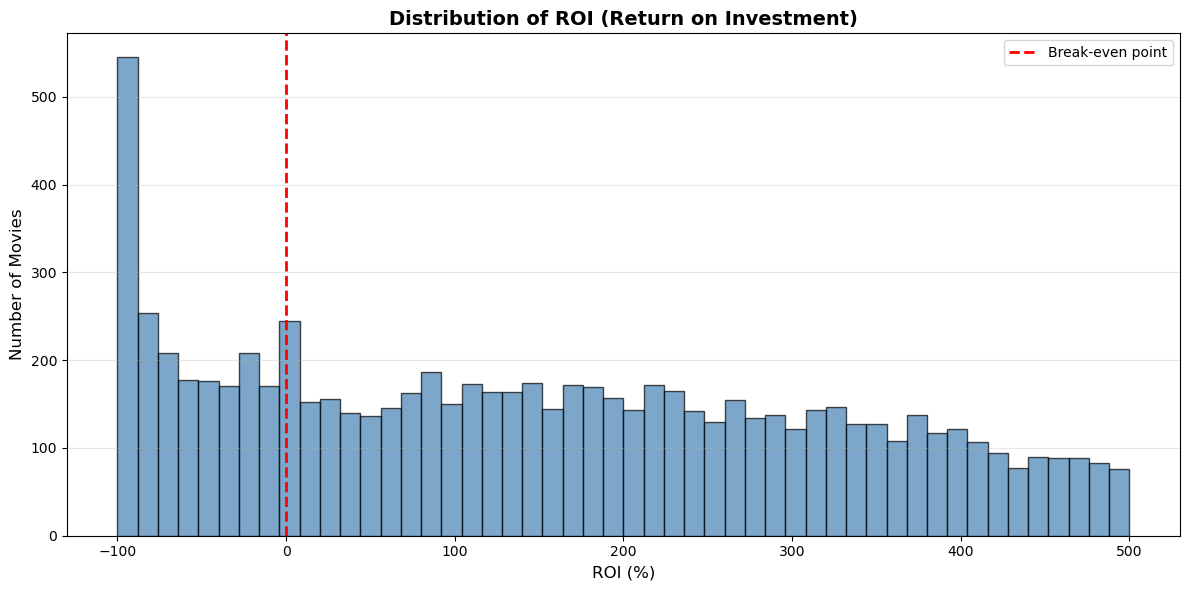


TASK 6: FIND MOST POPULAR GENRE BY COUNTRY

Finding the most popular genre for each country...

Top 10 countries by number of films:
country
AU    4885
US    2750
JP     538
KR     361
FR     222
GB     174
ES     153
HK     125
IT     123
MX     105
Name: count, dtype: int64

----------------------------------------------------------------------
MOST POPULAR GENRE BY COUNTRY (Top 10 countries):
----------------------------------------------------------------------
Country  Total Movies Most Popular Genre  Genre Count Percentage
     AU          4885              Drama          199       4.1%
     US          2750              Drama          123       4.5%
     JP           538              Drama           28       5.2%
     KR           361            Romance          101      28.0%
     FR           222              Drama           27      12.2%
     GB           174        Documentary           14       8.0%
     ES           153              Drama           17      11.1%
     HK  

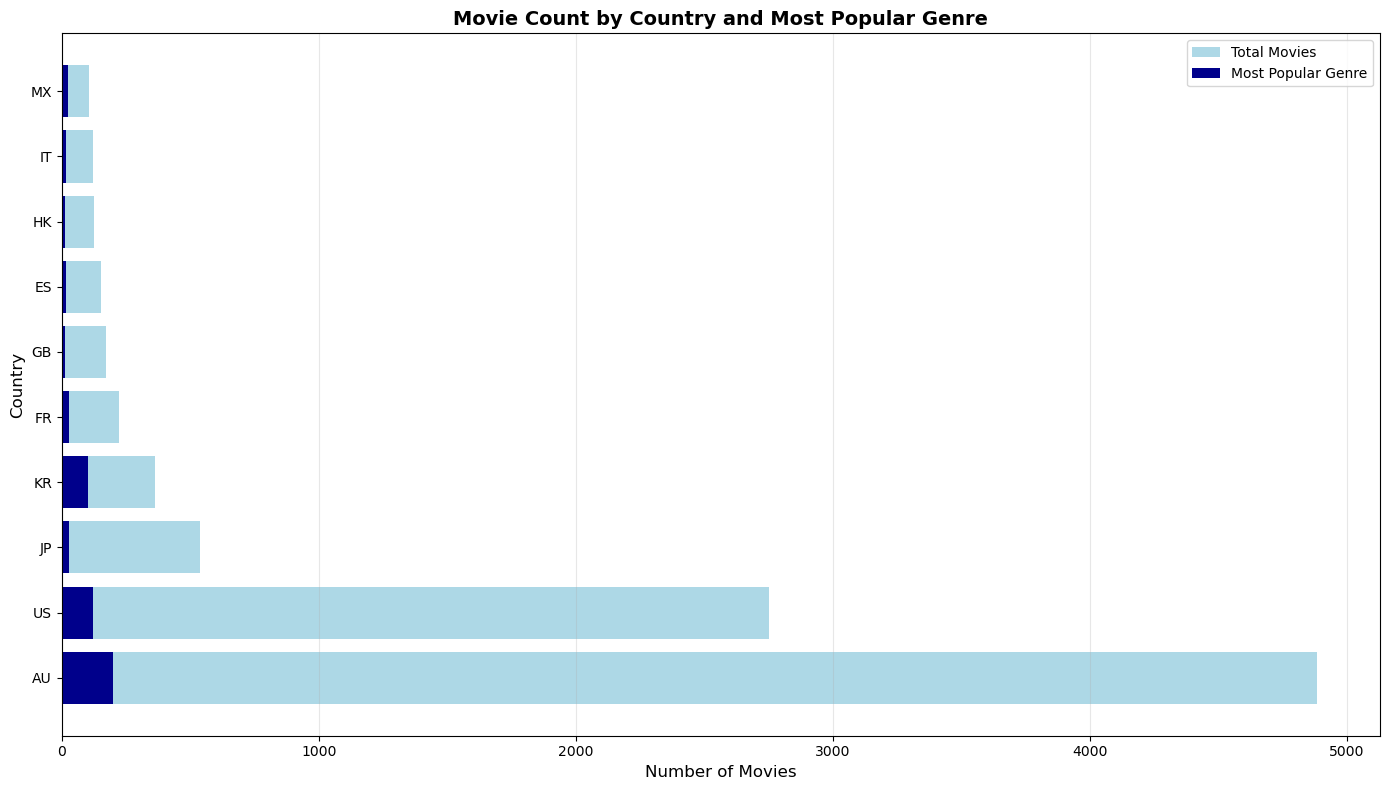


ADDITIONAL ANALYSIS

Genre diversity (unique genres per country) - Top 10:
country
AU    1478
US     916
JP     276
FR     120
KR     115
GB     107
HK      81
CN      73
ES      69
IT      60
Name: genre, dtype: int64

----------------------------------------------------------------------
Average movie score by country - Top 10:
country
SU    79.800000
PR    76.000000
XC    76.000000
CZ    72.500000
DO    72.000000
PY    71.000000
MU    70.000000
MX    69.771429
GT    68.000000
DK    67.333333
Name: score, dtype: float64

----------------------------------------------------------------------
Total revenue by country - Top 10:
  AU                            : $942,538,506,954
  US                            : $744,070,395,253
  JP                            : $219,561,174,560
  KR                            : $126,360,877,828
  FR                            : $67,850,271,479
  ES                            : $52,871,219,897
  GB                            : $51,482,745,973
  MX      

C:\Users\aslan\AppData\Local\Temp\ipykernel_12656\2685921511.py:241: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  genre_diversity = df.groupby('country')['genre'].nunique().sort_values(ascending=False)
C:\Users\aslan\AppData\Local\Temp\ipykernel_12656\2685921511.py:247: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_score_by_country = df.groupby('country')['score'].mean().sort_values(ascending=False)
C:\Users\aslan\AppData\Local\Temp\ipykernel_12656\2685921511.py:253: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False t

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


print("=" * 70)
print("TASK 1: MEMORY OPTIMIZATION")
print("=" * 70)

# Task 1: Memory Optimization
# Save current memory usage
memory_before = df.memory_usage(deep=True).sum()

print(f"\nMemory usage BEFORE optimization: {memory_before:,} bytes")
print(f"Memory usage BEFORE optimization: {memory_before / 1024**2:.2f} MB")

print("\nMemory breakdown by column (BEFORE):")
memory_by_column_before = df.memory_usage(deep=True)
for col, mem in memory_by_column_before.items():
    print(f"  {col:20s}: {mem / 1024**2:8.2f} MB")

# Convert to category type
print("\n" + "-" * 70)
print("Converting columns to 'category' dtype...")
print("-" * 70)

# Check if columns exist (they might have been created in Part 3)
columns_to_convert = []
if 'genre' in df.columns:
    columns_to_convert.append('genre')
if 'country' in df.columns:
    columns_to_convert.append('country')
if 'orig_lang' in df.columns:
    columns_to_convert.append('orig_lang')
if 'performance' in df.columns:
    columns_to_convert.append('performance')

print(f"\nColumns to convert: {columns_to_convert}")

for col in columns_to_convert:
    print(f"  Converting '{col}' to category...")
    df[col] = df[col].astype('category')

# Measure new memory usage
memory_after = df.memory_usage(deep=True).sum()

print(f"\n✓ Conversion complete!")
print(f"\nMemory usage AFTER optimization: {memory_after:,} bytes")
print(f"Memory usage AFTER optimization: {memory_after / 1024**2:.2f} MB")

print("\nMemory breakdown by column (AFTER):")
memory_by_column_after = df.memory_usage(deep=True)
for col, mem in memory_by_column_after.items():
    print(f"  {col:20s}: {mem / 1024**2:8.2f} MB")

# Calculate savings
memory_saved = memory_before - memory_after
memory_saved_pct = (memory_saved / memory_before) * 100

print("\n" + "=" * 70)
print("TASK 2: COMPARE MEMORY USAGE")
print("=" * 70)

print(f"\nMemory BEFORE: {memory_before / 1024**2:,.2f} MB")
print(f"Memory AFTER:  {memory_after / 1024**2:,.2f} MB")
print(f"Memory SAVED:  {memory_saved / 1024**2:,.2f} MB ({memory_saved_pct:.1f}%)")

print("\n" + "-" * 70)
print("EXPLANATION:")
print("-" * 70)
print("""
Converting string columns with limited unique values to 'category' dtype 
significantly reduces memory usage because categories store data as integer 
codes with a mapping table, rather than storing full strings for each row.
This is especially effective for columns like 'genre', 'country', and 
'orig_lang' which have high repetition and limited unique values.
""")

print("\n" + "=" * 70)
print("TASK 3: USE .query() FOR COMPLEX FILTERING")
print("=" * 70)

# Task 3: Use .query() for filtering
print("\nFinding movies that are:")
print("  1. Profitable (profit > 0)")
print("  2. In English (orig_lang == 'EN' or lang_code == 'EN')")
print("  3. With rating > 7.0")

# Check which language column to use
if 'lang_code' in df.columns:
    profitable_en = df.query("profit > 0 and lang_code == 'EN' and score > 7.0")
    lang_filter = "lang_code == 'EN'"
elif 'orig_lang' in df.columns:
    profitable_en = df.query("profit > 0 and orig_lang == 'English' and score > 7.0")
    lang_filter = "orig_lang == 'English'"
else:
    print("\n⚠️ Warning: No language column found. Using only profit and score filters.")
    profitable_en = df.query("profit > 0 and score > 7.0")
    lang_filter = "N/A"

print(f"\nQuery used: profit > 0 and {lang_filter} and score > 7.0")
print(f"\nNumber of movies found: {len(profitable_en)}")
print(f"Percentage of total: {len(profitable_en) / len(df) * 100:.1f}%")

print("\n" + "-" * 70)
print("Top 10 profitable English movies by score:")
print("-" * 70)
print(profitable_en.nlargest(10, 'score')[['names', 'score', 'profit', 'budget', 'revenue']])

print("\n" + "=" * 70)
print("TASK 4: USE .eval() TO CREATE A COLUMN")
print("=" * 70)

# Task 4: Use .eval() to create budget_revenue_ratio column
print("\nCreating 'budget_revenue_ratio' column using .eval()...")

# Handle division by zero
df['budget_revenue_ratio'] = df.eval('revenue / budget', engine='python')
# Replace inf values (when budget is 0) with NaN
df['budget_revenue_ratio'] = df['budget_revenue_ratio'].replace([np.inf, -np.inf], np.nan)

print("✓ Column created!")
print("\nSample data with budget_revenue_ratio:")
print(df[['names', 'budget', 'revenue', 'budget_revenue_ratio']].head(10))

print("\nStatistics for budget_revenue_ratio:")
print(df['budget_revenue_ratio'].describe())

print("\n" + "=" * 70)
print("TASK 5: CALCULATE ROI (RETURN ON INVESTMENT)")
print("=" * 70)

# Task 5: Calculate ROI
print("\nCalculating ROI: (revenue - budget) / budget * 100")
print("Note: Handling cases where budget == 0...")

# Create ROI column, handling budget == 0
df['roi'] = np.where(
    df['budget'] > 0,
    (df['revenue'] - df['budget']) / df['budget'] * 100,
    np.nan  # Set to NaN when budget is 0
)

print("✓ ROI column created!")

# Find top 10 films with highest ROI
print("\n" + "-" * 70)
print("TOP 10 FILMS WITH HIGHEST ROI:")
print("-" * 70)

top_roi = df.nlargest(10, 'roi')[['names', 'budget', 'revenue', 'profit', 'roi']]
print(top_roi.to_string())

# Additional statistics
print("\n" + "-" * 70)
print("ROI STATISTICS:")
print("-" * 70)
print(df['roi'].describe())

print(f"\nMovies with positive ROI: {(df['roi'] > 0).sum()}")
print(f"Movies with negative ROI: {(df['roi'] < 0).sum()}")
print(f"Movies with no ROI data (budget = 0): {df['roi'].isna().sum()}")

# Visualize ROI distribution
plt.figure(figsize=(12, 6))
# Filter out extreme outliers for better visualization
roi_filtered = df['roi'].dropna()
roi_filtered = roi_filtered[(roi_filtered >= -100) & (roi_filtered <= 500)]

plt.hist(roi_filtered, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of ROI (Return on Investment)', fontsize=14, fontweight='bold')
plt.xlabel('ROI (%)', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Break-even point')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("TASK 6: FIND MOST POPULAR GENRE BY COUNTRY")
print("=" * 70)

# Task 6: Most popular genre by country
print("\nFinding the most popular genre for each country...")

# Count movies by country
country_counts = df['country'].value_counts()
top_10_countries = country_counts.head(10).index

print(f"\nTop 10 countries by number of films:")
print(country_counts.head(10))

print("\n" + "-" * 70)
print("MOST POPULAR GENRE BY COUNTRY (Top 10 countries):")
print("-" * 70)

# For each top country, find the most popular genre
results = []
for country in top_10_countries:
    country_data = df[df['country'] == country]
    most_popular_genre = country_data['genre'].value_counts().head(1)
    
    if len(most_popular_genre) > 0:
        genre = most_popular_genre.index[0]
        count = most_popular_genre.values[0]
        total = len(country_data)
        percentage = (count / total) * 100
        
        results.append({
            'Country': country,
            'Total Movies': total,
            'Most Popular Genre': genre,
            'Genre Count': count,
            'Percentage': f"{percentage:.1f}%"
        })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Visualize
plt.figure(figsize=(14, 8))
x = range(len(results_df))
plt.barh(x, results_df['Total Movies'], color='lightblue', label='Total Movies')
plt.barh(x, results_df['Genre Count'], color='darkblue', label='Most Popular Genre')
plt.yticks(x, results_df['Country'])
plt.xlabel('Number of Movies', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.title('Movie Count by Country and Most Popular Genre', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("ADDITIONAL ANALYSIS")
print("=" * 70)

# Genre diversity by country
print("\nGenre diversity (unique genres per country) - Top 10:")
genre_diversity = df.groupby('country')['genre'].nunique().sort_values(ascending=False)
print(genre_diversity.head(10))

# Average score by country
print("\n" + "-" * 70)
print("Average movie score by country - Top 10:")
avg_score_by_country = df.groupby('country')['score'].mean().sort_values(ascending=False)
print(avg_score_by_country.head(10))

# Total revenue by country
print("\n" + "-" * 70)
print("Total revenue by country - Top 10:")
revenue_by_country = df.groupby('country')['revenue'].sum().sort_values(ascending=False)
for country, revenue in revenue_by_country.head(10).items():
    print(f"  {country:30s}: ${revenue:,.0f}")

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"""
✓ Memory optimized: {memory_saved_pct:.1f}% reduction
✓ Found {len(profitable_en)} profitable English movies with score > 7.0
✓ Created budget_revenue_ratio column
✓ Calculated ROI for {(~df['roi'].isna()).sum()} movies
✓ Analyzed most popular genres for top 10 countries
""")